### Practical Work

1. Train a RF on TF-8Bind data. 
2. Predict new sequences with SMW from seed sequence
3. Score unique unssen predicted sequences
4. best sequence == new seed
5. plot how good prediciton is against real world labels


In [13]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

from split.create_split import create_split

# LSTM model^
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEED = 42

### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [2]:
# Load dataset
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)
df.head()

,0,1,2,3,4,5,6,7,sequence,binding_scores,split,cluster,distance_to_seed
0,0,0,0,0,0,0,0,0,AAAAAAAA,0.524749,test_a,30,3
1,0,0,0,0,0,0,0,1,AAAAAAAC,0.366511,test_c,10,3
2,0,0,0,0,0,0,0,2,AAAAAAAG,0.446759,test_a,26,3
3,0,0,0,0,0,0,0,3,AAAAAAAT,0.455201,test_c,10,4
4,0,0,0,0,0,0,1,0,AAAAAACA,0.512627,test_a,30,3


In [3]:
train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-5].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values


X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = np.array([tf.one_hot(seq, depth=4).numpy().flatten() for seq in X_train])
X_val_onehot = np.array([tf.one_hot(seq, depth=4).numpy().flatten() for seq in X_val])


Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


2026-01-18 14:53:45.773450: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [42]:
# create dataframe for lookup task
test_df = df[df['split'] == 'test_c'] # use test_b for oracle evaluation

df_oracle = test_df[['0', '1', '2', '3', '4', '5', '6', '7', 'binding_scores']] # try oracle with all sequences df instead of only train_df
x_oracle = df_oracle.iloc[:, :-1].values
df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)

# print highest value and lowest value in oracle
print(f'Oracle binding score range: {df_oracle["binding_scores"].min()} - {df_oracle["binding_scores"].max()}')

Oracle binding score range: 0.003277945 - 1.0


/tmp/ipykernel_114279/2792261437.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oracle['one_hot_seq'] = [tf.one_hot(seq, depth=4).numpy().flatten() for seq in x_oracle]
/tmp/ipykernel_114279/2792261437.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oracle.drop(columns=df_oracle.columns[:-2], inplace=True)


In [43]:
def oracle_lookup(one_hot_sequence):
    """Looks up the real binding score for a given one-hot encoded sequence."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    if not match.empty:
        return match['binding_scores'].values[0]
    else:
        return 0.0  # no score if not found
    
def oracle_exists(one_hot_sequence):
    """Checks if a given one-hot encoded sequence exists in the oracle dataframe."""
    flattened_seq = one_hot_sequence.flatten()
    match = df_oracle[df_oracle['one_hot_seq'].apply(lambda x: np.array_equal(x, flattened_seq))]
    return not match.empty

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_onehot, y_train)
print(f'Best params: {rf_search.best_params_}')
print(f'Best CV R2: {rf_search.best_score_}')
print(f'Test R2: {r2_score(y_val, rf_search.predict(X_val_onehot))}')

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 500}
Best CV R2: 0.1350118179828936
Test R2: 0.1690129506546706


In [6]:
from scipy.stats import spearmanr
rf = RandomForestRegressor(n_estimators=500,
    max_depth=15,          # Limit tree depth
    min_samples_leaf=3,    # Require more samples per leaf
    min_samples_split=10,  # Require more samples to split
    max_features='sqrt',   # Use subset of features
    random_state=SEED
)

rf.fit(X_train_onehot, y_train)

# Evaluation just on a few samples from test set
#x_test = X_val.reshape(X_val.shape[0], y_train)

y_prediction = rf.predict(X_val_onehot)
r2 = r2_score(y_val, y_prediction)
mse = mean_squared_error(y_val, y_prediction)
spearmanr_corr, _ = spearmanr(y_val, y_prediction)
print(f'Spearmanr correlation: {spearmanr_corr}')
r2_train = r2_score(y_train, rf.predict(X_train_onehot))
print(f'R2 Score on train set: {r2_train}')
print(f'R2 Score: {r2}; MSE: {mse}')

Spearmanr correlation: 0.3871696804737996
R2 Score on train set: 0.3620882684168135
R2 Score: 0.1690129506546706; MSE: 0.004856086910758166


In [9]:
import numpy as np
import tensorflow as tf

class SMW:

    def __init__(self, nucleotides):
        self.nucleotides = nucleotides
        self.n = len(nucleotides)

    def one_hot_encode(self, sequence):
        sequence_tensor = tf.one_hot(
            sequence, depth=4
        )
        sequence_numpy = sequence_tensor.numpy() 
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

    def mutate_sequence(self, sequence, pos):
        sequence = list(sequence)
        if pos is None:
            pos = np.random.randint(0, len(sequence))
        # Get current nucleotide and possible mutations, make sure that nuc is different
        current_nucleotide = sequence[pos]
        possible_mutations = [nuc for nuc in self.nucleotides if nuc !=
                                current_nucleotide]
        # Replace nucleotide at position 
        new_nucleotide = np.random.choice(possible_mutations)
        sequence[pos] = new_nucleotide
        return sequence
        
    def walk(self, start_sequence, n_steps):
        current_seq = start_sequence
        history = []
        for step in range(n_steps):
            mutant = self.mutate_sequence(current_seq, None)
            mutant_one_hot = self.one_hot_encode(mutant)
            #mutant_fitness = fitness_function(mutant_one_hot)

            # Check if mutant is better than current
            # Yes: move to mutant
            #if mutant_fitness > current_fitness:
            current_seq = mutant
            #    current_fitness = mutant_fitness

            history.append(mutant_one_hot)
        return history


#### LSTM Model 

In [109]:
#Lstm model for sequence generation
model = Sequential()
model.add(LSTM(100, input_shape = (x.shape[1:])))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.load_weights('lstm_sequence_model.h5')

model.summary()

def generate_sequence(seed_sequence, next_chars, max_sequence_len):
    for _ in range(next_chars):
        token_list = tf.one_hot(seed_sequence, depth=4)
        token_list = tf.reshape(token_list, (1, token_list.shape[0], token_list.shape[1]))
        predicted = model.predict(token_list, verbose=0)
        predicted_char = tf.argmax(predicted, axis=1).numpy()[0]
        seed_sequence.append(predicted_char)
        if len(seed_sequence) > max_sequence_len:
            seed_sequence = seed_sequence[1:]
    return seed_sequence

def generate_mutations(seed_sequence, n_mutations):
    mutations = []
    seed_sequence = seed_sequence[-1]
    for _ in range(n_mutations):
        mutated_sequence = generate_sequence(seed_sequence.copy(), next_chars=1, max_sequence_len=len(seed_sequence))
        mutations.append(mutated_sequence)
        seed_sequence = mutated_sequence[-1] # update seed to last generated character
    return mutations


/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,404 (165.64 KB)

 Trainable params: 42,404 (165.64 KB)

 Non-trainable params: 0 (0.00 B)

### Another Approach
1. One Mutation from Single Mutant Walker
2. Predict with RF
3. Normalize Predicted score to range 0-1
4. If score is higher -> save sequence else continue with old seed
5. Lookup real scores and plot trajectories

Starting seed sequence: [2 2 1 0 0 1 1 1] with binding score 0.24010432
Step 1/100, New best mutation with predicted score: 0.3010441476547435
Step 1/100, New best mutation with predicted score: 0.3311415662973745
Step 1/100, New best mutation with predicted score: 0.34283737603082337
Step 1/100, New best mutation with predicted score: 0.36173607408991887
Step 2/100, New best mutation with predicted score: 0.3636656067657148
Step 2/100, New best mutation with predicted score: 0.36626100762883335
Step 2/100, New best mutation with predicted score: 0.3736588930327464
Step 11/100, New best mutation with predicted score: 0.38154743038953226
Step 17/100, New best mutation with predicted score: 0.3829600081928576
Step 24/100, New best mutation with predicted score: 0.3829822517789193
Step 55/100, New best mutation with predicted score: 0.3843699710748321


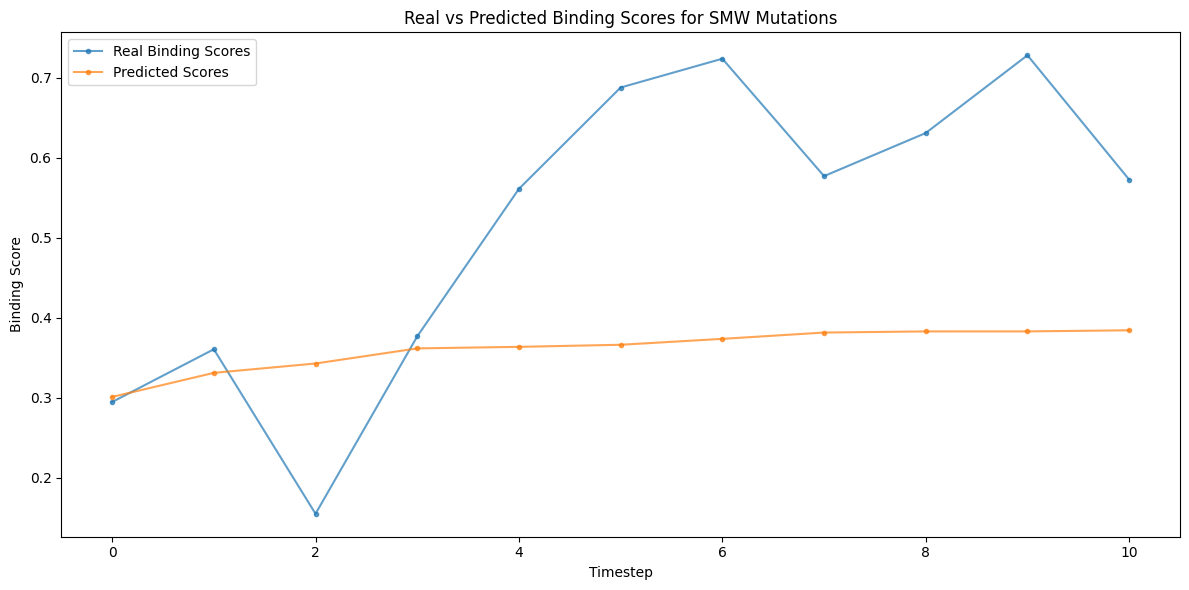

In [44]:
# Initialize SMW 
smw = SMW(nucleotides=[0, 1, 2, 3])
n_steps = 100
mutation_steps = 10

seen_sequences = X_train_onehot

#select a random seed sequence from training data
seed_sequence = X_train[0]
old_binding_score = y_train[0]
print(f'Starting seed sequence: {seed_sequence} with binding score {old_binding_score}')
#seed_sequence = tf.argmax(X_train[1300], axis=1).numpy().tolist()


values = {'mutation': [], 'predicted_score': []}

min_score = df_oracle['binding_scores'].min()
max_score = df_oracle['binding_scores'].max()

for i in range(n_steps):
    # Generate one mutation using SMW
    mutations = smw.walk(seed_sequence, mutation_steps)  # Get the first mutation
    # Check if mutation is new
    for idx, mutation in enumerate(mutations):
        already_seen = np.any(np.all(seen_sequences == mutation, axis=1))
        if not already_seen and oracle_exists(mutation):
            binding_score = rf.predict(mutation)
            if binding_score[0] > old_binding_score:
                # Update seed sequence
                seed_sequence = tf.argmax(tf.reshape(mutation, (mutation.shape[1]//4, 4)), axis=1).numpy().tolist()
                old_binding_score = binding_score[0]
                values['mutation'].append(mutation)
                # normalize binding score to 0-1 range based on oracle min/max
                #normalized_score = -(binding_score[0] - min_score) / (max_score - min_score)
                values['predicted_score'].append(binding_score[0])
                print(f'Step {i+1}/{n_steps}, New best mutation with predicted score: {binding_score[0]}')
            else:
                continue

# Lookup real binding score
df_values = pd.DataFrame(values)
df_values['real_score'] = df_values['mutation'].apply(oracle_lookup)
df_values['error'] = abs(df_values['predicted_score'] - df_values['real_score'])

# Plot results 
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'], label='Real Binding Scores', alpha=0.7, marker='o', markersize=3)
plt.plot(df_values['predicted_score'], label='Predicted Scores', alpha=0.7, marker='o', markersize=3)
plt.xlabel('Timestep')
plt.ylabel('Binding Score')
plt.title('Real vs Predicted Binding Scores for SMW Mutations')
plt.legend()
plt.tight_layout()
plt.show()

Notes:
1. Testset A: spearman Correlation: 0.683, direction_agreement 66.7%
2. Testset B: spearman Correlation: 0.524, direction_agreement 58.3%
3. Testset C: spearman Correlation: 0.764, direction_agreement 72.7

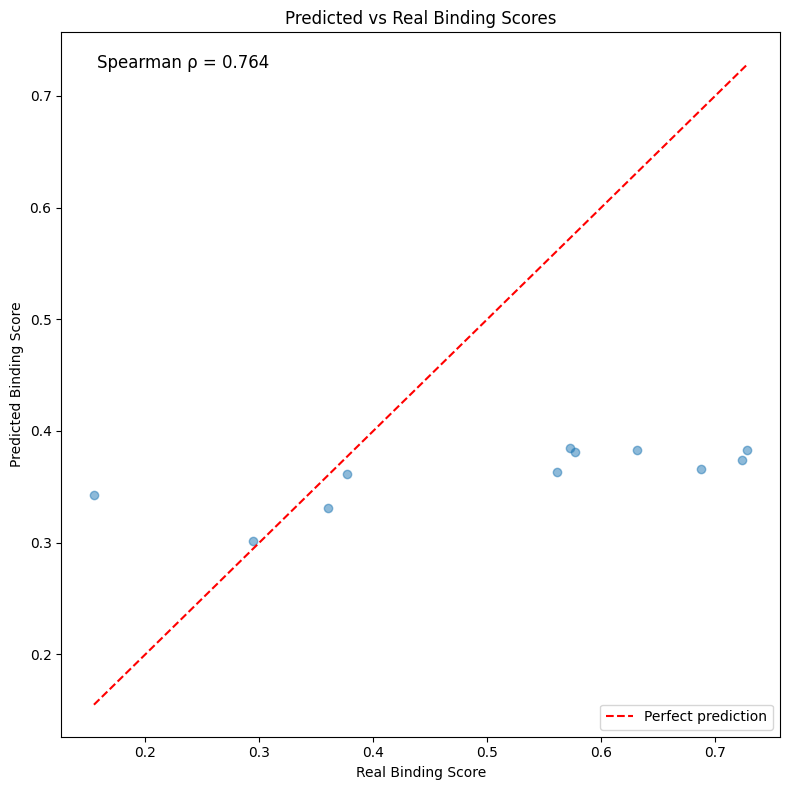

In [45]:
# Scatter plot shows correlation regardless of absolute values
plt.figure(figsize=(8, 8))
plt.scatter(df_values['real_score'], df_values['predicted_score'], alpha=0.5)
plt.plot([df_values['real_score'].min(), df_values['real_score'].max()], 
         [df_values['real_score'].min(), df_values['real_score'].max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Real Binding Score')
plt.ylabel('Predicted Binding Score')
plt.title('Predicted vs Real Binding Scores')
plt.legend()

# Add Spearman correlation to plot
from scipy.stats import spearmanr
corr, _ = spearmanr(df_values['real_score'], df_values['predicted_score'])
plt.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.tight_layout()
plt.show()

Direction agreement: 72.7%


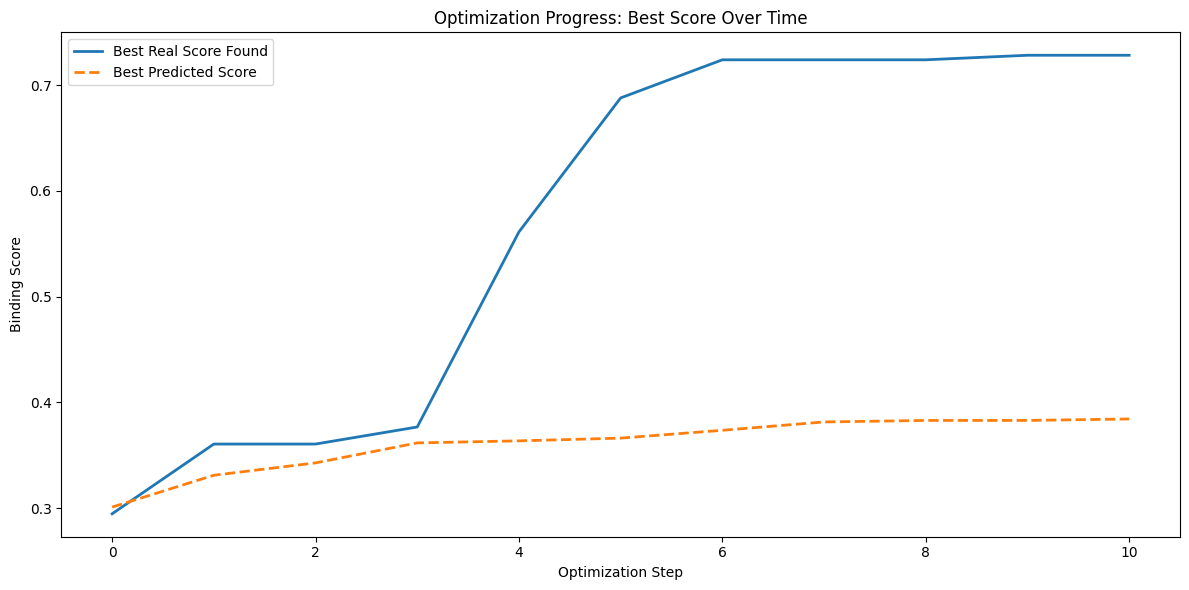

In [47]:
# What matters: Did real scores also improve when predicted scores improved?
df_values['real_score_improved'] = df_values['real_score'].diff() > 0
df_values['pred_score_improved'] = df_values['predicted_score'].diff() > 0

# How often did both agree on direction?
agreement = (df_values['real_score_improved'] == df_values['pred_score_improved']).mean()
print(f'Direction agreement: {agreement:.1%}')

# Plot cumulative real score improvement
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'].cummax(), label='Best Real Score Found', linewidth=2)
plt.plot(df_values['predicted_score'].cummax(), label='Best Predicted Score', linewidth=2, linestyle='--')
plt.xlabel('Optimization Step')
plt.ylabel('Binding Score')
plt.title('Optimization Progress: Best Score Over Time')
plt.legend()
plt.tight_layout()
plt.show()

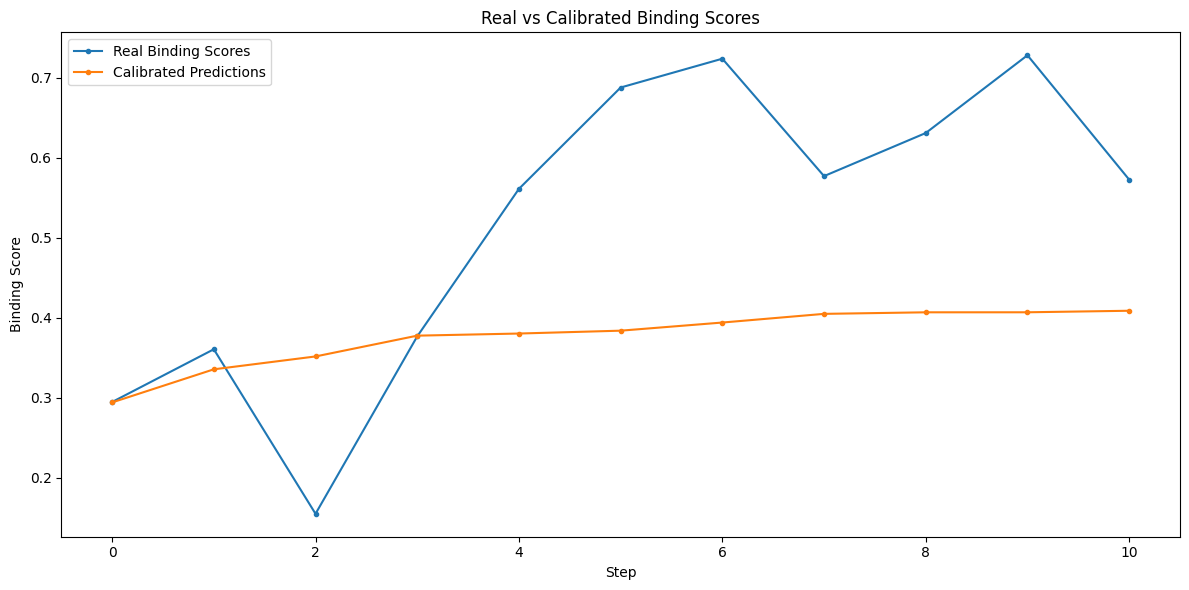

Calibration: predicted * 1.376 + -0.120


In [48]:
from sklearn.linear_model import LinearRegression

# Use validation set to learn a calibration mapping
y_val_pred = rf.predict(X_val_onehot)

# Fit linear calibration: real = a * predicted + b
calibrator = LinearRegression()
calibrator.fit(y_val_pred.reshape(-1, 1), y_val)

# Apply calibration to your results
df_values['calibrated_score'] = calibrator.predict(
    np.array(df_values['predicted_score']).reshape(-1, 1)
)

# Plot calibrated results
plt.figure(figsize=(12, 6))
plt.plot(df_values['real_score'].values, label='Real Binding Scores', marker='o', markersize=3)
plt.plot(df_values['calibrated_score'].values, label='Calibrated Predictions', marker='o', markersize=3)
plt.xlabel('Step')
plt.ylabel('Binding Score')
plt.title('Real vs Calibrated Binding Scores')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Calibration: predicted * {calibrator.coef_[0]:.3f} + {calibrator.intercept_:.3f}')

### Plot the trajcectories into a Scatterplot

/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_114279/202568369.py:62: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1],
/tmp/ipykernel_114279/202568369.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1],


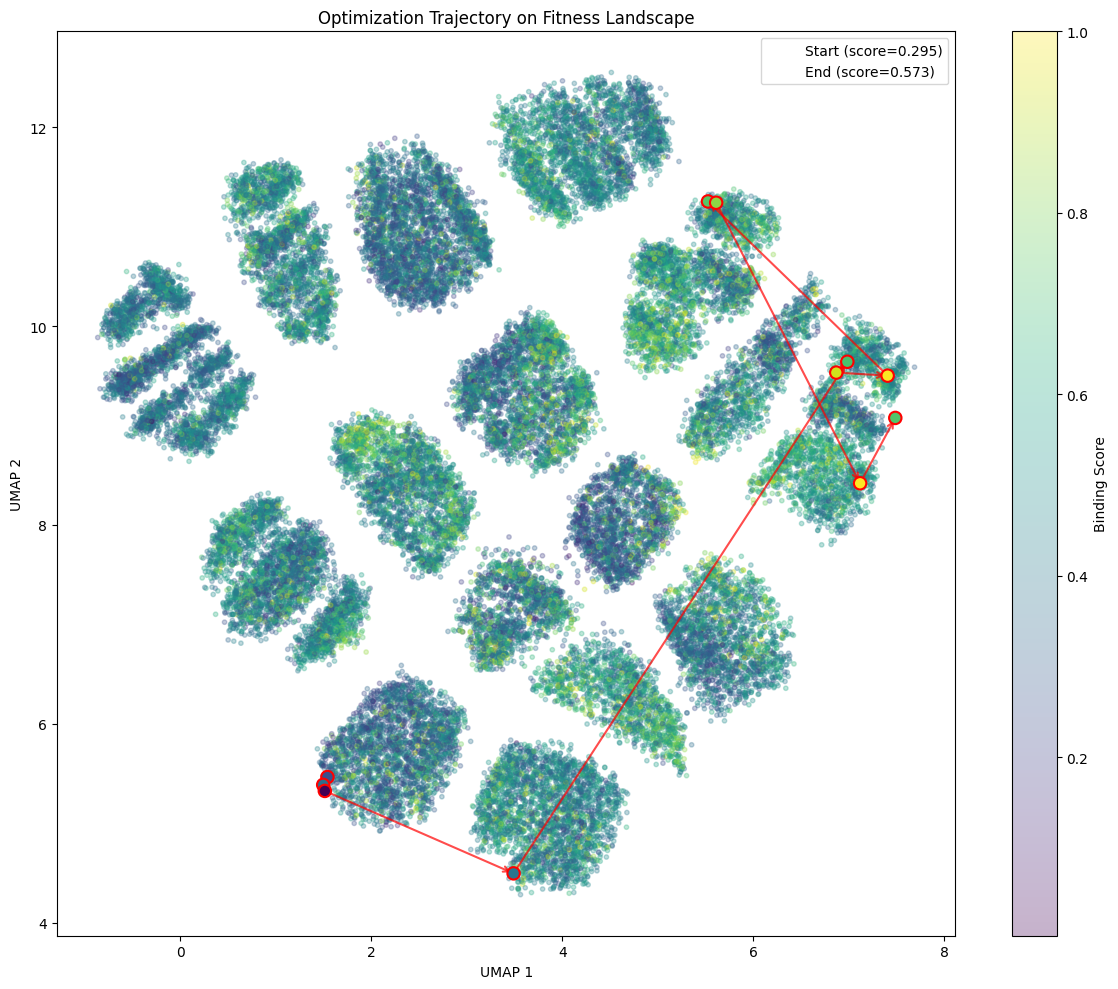

In [49]:
from matplotlib.patches import FancyArrowPatch
import umap
from sklearn.preprocessing import StandardScaler

# Prepare all sequences for embedding (oracle + trajectory)
X_oracle_onehot = np.vstack(df_oracle['one_hot_seq'].values)
X_trajectory = np.vstack(df_values['mutation'].values)

# Combine for consistent embedding
X_combined = np.vstack([X_oracle_onehot, X_trajectory])

# Fit UMAP on combined data
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Split back
n_oracle = len(X_oracle_onehot)
embedding_oracle = embedding[:n_oracle]
embedding_trajectory = embedding[n_oracle:]

# Get scores for coloring
oracle_scores = df_oracle['binding_scores'].values
trajectory_real_scores = df_values['real_score'].values


fig, ax = plt.subplots(figsize=(12, 10))


# Background landscape
scatter = ax.scatter(
    embedding_oracle[:, 0], 
    embedding_oracle[:, 1], 
    c=oracle_scores, 
    cmap='viridis', 
    alpha=0.3, 
    s=10
)
plt.colorbar(scatter, label='Binding Score')

# Draw arrows between consecutive trajectory points
for i in range(len(embedding_trajectory) - 1):
    ax.annotate(
        '', 
        xy=(embedding_trajectory[i+1, 0], embedding_trajectory[i+1, 1]),
        xytext=(embedding_trajectory[i, 0], embedding_trajectory[i, 1]),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7)
    )

# Trajectory points colored by score
ax.scatter(
    embedding_trajectory[:, 0], 
    embedding_trajectory[:, 1], 
    c=trajectory_real_scores,
    cmap='viridis',
    edgecolors='red',
    linewidths=1.5,
    s=80,
    zorder=5
)

# Start and end markers
ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1], 
           c='lime', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'Start (score={trajectory_real_scores[0]:.3f})', zorder=10)
ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1], 
           c='red', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'End (score={trajectory_real_scores[-1]:.3f})', zorder=10)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Optimization Trajectory on Fitness Landscape')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fitness_landscape_trajectory_testset_C.png', dpi=150)
plt.show()